# **Explorar la Base de Datos para Examinar los Parámetros Disponibles y Evaluar la Calidad de los Registros**

## **Librerías Importadas**

In [28]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [29]:
pd.options.display.float_format = '{:,.2f}'.format

## **Lectura de Datos**

In [30]:
df = pd.read_excel('datos.xlsx')

## **Delimitación Temporal de la Muestra**

Los registros disponibles abarcan desde 2017 hasta marzo de 2026; sin embargo, al contar únicamente con el primer trimestre de 2026, se opta por filtrar este año para mantener la consistencia del análisis, quedándonos con el período 2017–2025.

In [31]:
df = df[df['año'] != 26]
df = df.reset_index(drop=True)

## **Inspección Inicial de los Datos**

Se ejecuta el método `.info()` para obtener un resumen del conjunto de datos depurado, que incluye el total de entradas, el rango de índices, los tipos de cada variable y la memoria utilizada.

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 40 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   codigo                                               3387 non-null   str    
 1   edad                                                 3387 non-null   float64
 2   dias_abstinencia                                     3387 non-null   int64  
 3   nombre                                               3387 non-null   str    
 4   volumen_ml                                           3384 non-null   float64
 5   ph                                                   2896 non-null   float64
 6   mucolisis                                            3354 non-null   str    
 7   viscosidad                                           3355 non-null   str    
 8   color                                                3348 non-null   str    
 9

**Resumen General**

Este DataFrame contiene 3,387 registros de análisis de semen (espermiogramas) con 40 columnas, lo que representa una base de datos clínica de fertilidad masculina.

**Estructura de los Datos**

- **1. Variables Identificativas**
    - `codigo`: Identificador único del paciente (string)
    - `nombre`: Nombre del paciente (string)
    - `identificacion`: Otro tipo de identificación (object, 3 valores nulos)
    - `año`: Año del estudio (int64)

- **2. Variables Demográficas**
    - `edad`: Edad del paciente (float64)
    - `dias_abstinencia`: Días de abstinencia sexual previa (int64, completo)

- **3. Variables del Seminograma (Principales)**

    - **Características Físicas:**
        - `volumen_ml`: Volumen de la muestra en ml (float64, 3 nulos)
        - `ph`: pH de la muestra (float64, 491 nulos)
        - `mucolisis`: Característica de la mucosidad (string, 33 nulos)
        - `viscosidad`: Grado de viscosidad (string, 32 nulos)
        - `color`: Color de la muestra (string, 39 nulos)
        - `olor`: Olor de la muestra (string, 559 nulos)

    - **Recuento Celular:**
        - `celulas_redondas`: Células redondas presentes (object, 244 nulos)
        - `leucocitos`: Presencia de leucocitos (object, 1,472 nulos)
        - `aglutinacion_pct`: Aglutinación (object, 1,107 nulos)
        - `espermatozoides_por_eyaculado`: Número total (float64, 2 nulos)
        - `concentracion_por_ml`: Concentración en millones/ml (float64, 2 nulos)

    - **Viabilidad y Motilidad:**
        - `test_eosina_pct`: Porcentaje de espermatozoides viables (float64, 572 nulos)
        - `motilidad_progresiva_pct`: % con movimiento progresivo (float64, 3 nulos)
        - `motilidad_no_progresiva_pct`: % con movimiento no progresivo (float64, 3 nulos)
        - `inmovil_pct`: % de espermatozoides inmóviles (float64, 3 nulos)
        - `motilidad_total_pct`: % de motilidad total (float64, 3 nulos)

    - **Morfología:**
        - `espermatozoides_normales_pct`: % normales (float64, 605 nulos)
        - `espermatozoides_anormales_pct`: % anormales (float64, 605 nulos)
        - `alt_cabeza_pct`: % alteraciones de cabeza (float64, 612 nulos)
        - `alt_cola_pct`: % alteraciones de cola (float64, 620 nulos)
        - `alt_pieza_intermedia_pct`: % alteraciones de pieza intermedia (float64, 611 nulos)
        - `indice_teratozoospermia`: Índice de teratozoospermia (float64, 613 nulos)

- **4. Variables Derivadas/Verificación**
    - `concentracion_total/volumen = concentracion_volumen`: Verificación de cálculo (string, 170 nulos)
    - `motilidad_suma_bien`: Verificación de suma de motilidades (string, 195 nulos)
    - `motilidad_inmovil_100`: Verificación de consistencia (string, completo)
    - `espermatozoides_normales_anormales=100`: Verificación de suma normales+anormales (string, completo)

- **5. Observaciones**
    - `comentarios`: Notas clínicas (string, 116 nulos)
    - `tipo_comentario`: Categoría del comentario (string, completo)
    - `otras_celulas`: Otras células presentes (string, 3,290 nulos)
    - `trazas_gel`: Presencia de trazas de gel (string, completo)
    - `examen_hora`: Hora del examen (string, 903 nulos)

- **6. Registros Adicionales**
    - `rem1`, `rem2`, `rem3`: Campos de observación/revisión (object)

**Fortalezas**
- Buen tamaño muestral (3,387 registros)
- Variables clínicas completas en su mayoría
- Incluye verificaciones de consistencia interna
- Cubre todos los parámetros clave de un espermograma estándar (OMS)

## **Análisis de Completitud de Datos en Registros**

Con el objetivo de evaluar la calidad e integridad de la base de datos de seminogramas, se procede a calcular un indicador de completitud para cada registro. Este indicador cuantifica el número total de campos no nulos presentes en cada fila del DataFrame, permitiendo identificar aquellos pacientes con información incompleta que podrían requerir un análisis más detallado o ser excluidos de estudios posteriores.

In [33]:
df["completitud"] = df.notna().sum(axis=1)
df["completitud"].describe()

count   3,387.00
mean       33.51
std         4.03
min        15.00
25%        34.00
50%        35.00
75%        36.00
max        39.00
Name: completitud, dtype: float64

**Resumen General**

Los resultados muestran que, en promedio, cada registro tiene 33.51 campos completos de un total de 40 columnas, lo que representa un 83.8% de completitud general. Esto indica una buena calidad de datos en términos de integridad.

**Análisis Detallado por Estadísticos**

- **1. Medidas de Tendencia Central**
    - **Media = 33.51**: Promedio de campos completos por registro
    - **Mediana (50%) = 35.00**: La mitad de los registros tienen 35 o más campos completos
    - **Media vs Mediana**: La media es ligeramente menor que la mediana (33.51 vs 35.00), lo que sugiere que hay algunos registros con valores extremadamente bajos (sesgo negativo)

- **2. Distribución Percentilar**
    - **25% (Q1) = 34.00**: El 25% de los registros tienen ≤ 34 campos completos (85% de completitud)
    - **75% (Q3) = 36.00**: El 75% de los registros tienen ≤ 36 campos completos (90% de completitud)
    - **Rango intercuartílico (IQR) = 2**: La mayoría de los registros (50% central) tienen entre 34 y 36 campos completos, indicando alta consistencia

- **3. Valores Extremos**
    - **Mínimo = 15.00**: El registro más incompleto solo tiene 15 campos (37.5% de completitud)
    - **Máximo = 39.00**: El registro más completo tiene 39 campos (97.5% de completitud)
    - **Rango = 24**: Gran variabilidad entre el peor y el mejor registro

- **4. Dispersión**
    - **Desviación estándar = 4.03**: Variabilidad moderada alrededor de la media
    - **Coeficiente de variación (CV) = 4.03/33.51 = 12.0%**: Dispersión relativamente baja, indicando consistencia en los datos

**Fortalezas**

- **Excelente calidad general**: 83.8% de completitud promedio es alto para datos clínicos
- **Datos mayoritariamente completos**: El valor Q3 = 36 significa que el 75% de los registros tienen 36 o menos campos completos (≤36), o equivalentemente que el 25% tiene 36 o más (≥36).
- **Baja variabilidad**: La mayoría de los registros son consistentes entre sí

## **Visualización de Patrones de Datos Faltantes**

Para identificar visualmente la distribución y los patrones de valores ausentes en el DataFrame, se emplea un gráfico de matriz de nulos (missingno matrix). 

Esta visualización permite detectar:
- Columnas con mayor proporción de datos faltantes.
- Patrones sistemáticos de valores ausentes.
- Posibles relaciones entre variables incompletas.
- Registros que concentran múltiples valores faltantes.

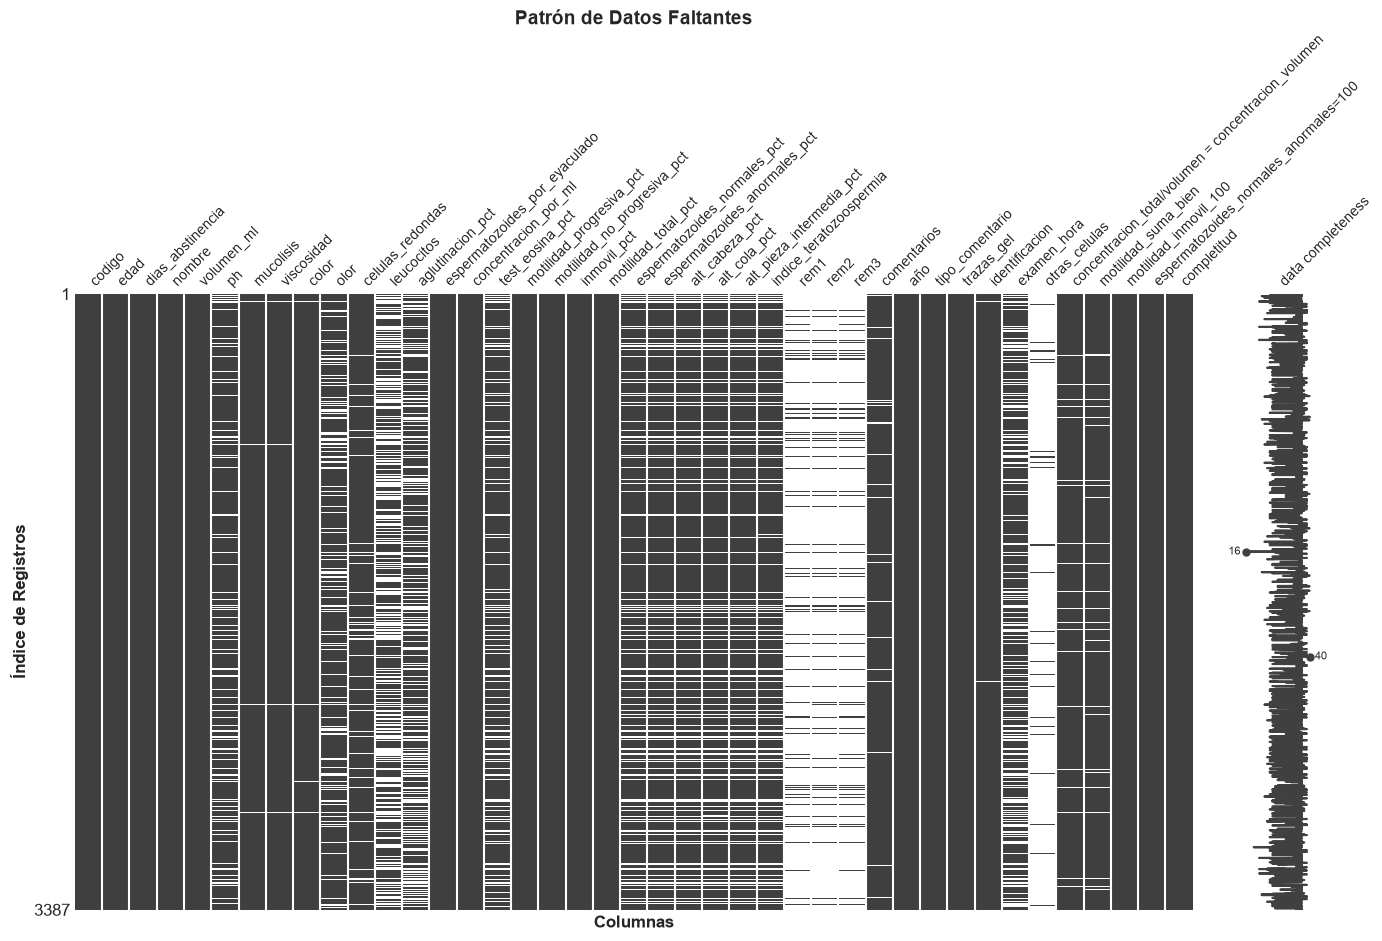

In [34]:
plt.style.use('seaborn-v0_8-whitegrid')

msno.matrix(
    df,
    figsize=(16, 8),
    fontsize=10,
    sparkline=True,  
    labels=True      
)
plt.title('Patrón de Datos Faltantes', fontsize=14, fontweight='bold')
plt.ylabel('Índice de Registros', fontsize=12, fontweight='bold')
plt.xlabel('Columnas', fontsize=12, fontweight='bold')

plt.show()

## **Análisis de Valores Faltantes por Variable**

Para complementar el análisis visual de datos ausentes, se elabora un resumen estadístico que cuantifica la cantidad y porcentaje de valores faltantes para cada una de las 40 variables del estudio. 

Este resumen permitirá:
- Identificar las variables con mayor proporción de datos ausentes.
- Establecer umbrales de exclusión para variables con excesivos nulos.
- Evaluar el impacto de los datos faltantes en análisis específicos.

In [35]:
resumen = pd.DataFrame({
    'No Nulos': df.count(),
    'Nulos': df.isnull().sum(),
    '% Faltantes': (df.isnull().sum() / len(df) * 100)
}).sort_values('% Faltantes', ascending=False)

display(resumen)

,No Nulos,Nulos,% Faltantes
otras_celulas,97,3290,97.14
rem2,334,3053,90.14
rem1,371,3016,89.05
rem3,374,3013,88.96
leucocitos,1915,1472,43.46
aglutinacion_pct,2280,1107,32.68
examen_hora,2484,903,26.66
alt_cola_pct,2767,620,18.31
indice_teratozoospermia,2774,613,18.10
alt_cabeza_pct,2775,612,18.07


**Resumen General**

El análisis de completitud por variable revela una base de datos con calidad heterogénea, donde encontramos desde variables perfectamente completas (0% nulos) hasta variables prácticamente vacías (97% nulos). Se identifican 4 grupos claramente diferenciados según el porcentaje de datos faltantes.

**Grupo 1: Variables Críticas (>30% Nulos)**

| Variable | Nulos | % Faltantes |
|----------|-------|-------------|
| `otras_celulas` | 3,290 | 97.14% |
| `rem2` | 3,053 | 90.14% |
| `rem1` | 3,016 | 89.05% |
| `rem3` | 3,013 | 88.96% |
| `leucocitos` | 1,472 | 43.46% |
| `aglutinacion_pct` | 1,107 | 32.68% |

**Grupo 2: Variables con Nulos Moderados (10-30%)**

| Variable | Nulos | % Faltantes |
|----------|-------|-------------|
| `examen_hora` | 903 | 26.66% |
| `alt_cola_pct` | 620 | 18.31% |
| `indice_teratozoospermia` | 613 | 18.10% |
| `alt_cabeza_pct` | 612 | 18.07% |
| `alt_pieza_intermedia_pct` | 611 | 18.04% |
| `espermatozoides_anormales_pct` | 605 | 17.86% |
| `espermatozoides_normales_pct` | 605 | 17.86% |
| `test_eosina_pct` | 572 | 16.89% |
| `olor` | 559 | 16.50% |
| `ph` | 491 | 14.50% |

- **Patrón Identificado**: Las variables de morfología (alt_cabeza, alt_cola, alt_pieza, índice, normales/anormales) tienen ~18% de nulos de manera consistente. Esto sugiere que los datos faltantes no son aleatorios, probablemente corresponden a muestras donde no se realizó el análisis morfológico completo.

**Grupo 3: Variables con Bajo Nivel de Nulos (1-10%)**

| Variable | Nulos | % Faltantes |
|----------|-------|-------------|
| `celulas_redondas` | 244 | 7.20% |
| `motilidad_suma_bien` | 195 | 5.76% |
| `concentracion_total/volumen = concentracion_volumen` | 170 | 5.02% |
| `comentarios` | 116 | 3.42% |
| `color` | 39 | 1.15% |

**Grupo 4: Variables Prácticamente Completas (<1% Nulos)**

| Variable | Nulos | % Faltantes |
|----------|-------|-------------|
| `mucolisis` | 33 | 0.97% |
| `viscosidad` | 32 | 0.94% |
| `volumen_ml` | 3 | 0.09% |
| `motilidad_progresiva_pct` | 3 | 0.09% |
| `motilidad_total_pct` | 3 | 0.09% |
| `identificacion` | 3 | 0.09% |
| `inmovil_pct` | 3 | 0.09% |
| `motilidad_no_progresiva_pct` | 3 | 0.09% |
| `concentracion_por_ml` | 2 | 0.06% |
| `espermatozoides_por_eyaculado` | 2 | 0.06% |
| 8 variables | 0 | 0.00% |


**Variables perfectas (0% nulos)**: `codigo`, `nombre`, `dias_abstinencia`, `edad`, `año`, `tipo_comentario`, `trazas_gel`, `motilidad_inmovil_100`, `espermatozoides_normales_anormales=100` y `completitud`

**Variables de Verificación**
- `motilidad_inmovil_100` (100% completa) - Buena señal de control de calidad
- `espermatozoides_normales_anormales=100` (100% completa) - Buena señal
- `motilidad_suma_bien` (94.24% completa) - Mayoría de registros consistentes

**Variables Clínicas Clave**

| Categoría | Variables | Completitud |
|-----------|-----------|-------------|
| Motilidad | Todas las de motilidad | 99.91% |
| Concentración | Concentración y total | 99.94% |
| Volumen | volumen_ml | 99.91% |
| Morfología | Todas las de morfología | ~82% |
| Viabilidad | test_eosina_pct | 83.11% |
| Leucocitos | leucocitos | 56.54% |

## **Exclusión de Variables**

La exclusión de estas variables se basa en criterios de calidad de datos (alto porcentaje de nulos), relevancia clínica (bajo valor predictivo) y robustez metodológica (evitar sesgos y pérdida de potencia estadística). El conjunto final de variables seleccionadas garantiza un análisis confiable con un tamaño muestral adecuado para cada variable incluida.

In [36]:
df = df.drop(columns=['olor','color','leucocitos','rem1','rem2','rem3', 'otras_celulas'])

Las variables `color`, `olor`, `leucocitos`, `otras_celulas` y `REM` (rem1, rem2, rem3) fueron conservadas en la base de datos original, sin embargo, no se incluyeron en el análisis exploratorio posterior debido a las siguientes razones:

**1. Variables descriptivas cualitativas: Color y Olor**

- **Naturaleza subjetiva**: Son variables cualitativas con escaso valor estadístico para modelos cuantitativos. Por tanto, la exclusión no está motivada por calidad de datos, sino por criterio clínico.
- **Bajo poder explicativo**: Aportan información clínica orientativa pero no significativa para análisis correlacionales
- **Limitaciones metodológicas**: Su evaluación depende de la percepción del técnico y condiciones de procesamiento

**2. Variables REM (rem1, rem2, rem3)**

- **Datos insuficientes**: Presentan entre 88.96% y 90.14% de valores faltantes
- **Campos obsoletos**: Probablemente corresponden a campos administrativos en desuso del sistema de registro
- **No representativos**: Los pocos registros con datos no son representativos de la muestra total

**3. Variable "otras_celulas"**

- **Datos prácticamente inexistentes**: 97% de valores faltantes (solo 97 registros completos)
- **Registro esporádico**: Solo se anotaba ante hallazgos excepcionales, introduciendo sesgo de notificación

**4. Variable "leucocitos"**

- **Alto porcentaje de faltantes**: 43.46% de datos ausentes (1,472 casos sin registro)
- **Conversación con expertos**: Los expertos manifestaron que esta variable no era de importancia en el estudio